# Sharp central-limit rates in one-dimensional Wasserstein distance

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:statistical-berry-esseen-w1`. Let $\alpha$ be centered with unit variance and define
$$
\alpha_n=(D_{1/\sqrt n})_\sharp\alpha^{*n},
\qquad n\geq 1.
$$
The universal Berry--Esseen estimate gives $\mathcal{W}_1(\alpha_n,\gamma)=O(n^{-1/2})$, but the sharp rate depends on the input law. We compare
$$
\mathcal{W}_1(\alpha_n,\gamma)
\sim
\begin{cases}
\dfrac{1}{2\sqrt n},&
\alpha=\dfrac12(\delta_{-1}+\delta_1),\\[2mm]
\dfrac{1+4e^{-3/2}}{10\sqrt{2\pi}}\dfrac1n,&
\alpha=\operatorname{Unif}[-\sqrt3,\sqrt3].
\end{cases}
$$
The first equivalent is a lattice continuity correction; the second is the fourth-cumulant term of the smooth Edgeworth expansion.


In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('IPython', 'ipython'),
    ('scipy', 'scipy'),
)
_OT4ML_REQUIRED_FILES = (

)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT


In [2]:
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
from scipy.signal import fftconvolve
from scipy.special import ndtr, ndtri
from scipy.stats import irwinhall

from figure_style import (
    BLUE,
    GRAY,
    LIGHT_GRAY,
    RED,
    VIOLET,
    box_axes,
    figure_dir,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

FIGURE_NAME = "statistical-berry-esseen-w1"
OUT = figure_dir(FIGURE_NAME)
THUMBNAIL = ROOT / "notebooks-figures" / "thumbnails" / f"{FIGURE_NAME}.png"
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)


## Exact $\mathcal{W}_1$ evaluation

For a discrete law $\alpha=\sum_i w_i\delta_{x_i}$, the quantile formula gives
$$
\mathcal{W}_1(\alpha,\gamma)
=
\sum_i\int_{s_{i-1}}^{s_i}|x_i-\Phi^{-1}(u)|\,\mathrm du,
\qquad
s_i=\sum_{j\leq i}w_j.
$$
The antiderivative $\int \Phi^{-1}(u)\,\mathrm du=-\varphi(\Phi^{-1}(u))$ makes the Bernoulli computation exact up to floating-point arithmetic.

For continuous laws, the one-dimensional CDF identity gives the complementary formula
$$
\mathcal{W}_1(\alpha,\gamma)
=
\int_{\mathbb R}|F_\alpha(x)-\Phi(x)|\,\mathrm dx.
$$
We apply it to the exact Irwin--Hall CDF of the normalized continuous-uniform sums, using deterministic adaptive quadrature rather than sampling. Up to affine rescaling, the corresponding density is a cardinal B-spline of degree $n-1$.


In [3]:
def gaussian_pdf(x):
    """Evaluate the standard Gaussian density.

    Args:
        x: Scalar or array of evaluation points.

    Returns:
        Standard Gaussian density evaluated at ``x``.
    """
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * x**2) / np.sqrt(2.0 * np.pi)


def gaussian_quantile_primitive(u):
    """Evaluate an antiderivative of the standard Gaussian quantile.

    The continuous extension of ``-phi(Phi^{-1}(u))`` is zero at both
    endpoints of ``[0, 1]``.

    Args:
        u: Quantile levels in ``[0, 1]``.

    Returns:
        Values of the quantile antiderivative at ``u``.
    """
    u = np.asarray(u, dtype=float)
    values = np.zeros_like(u)
    interior = (u > 0.0) & (u < 1.0)
    values[interior] = -gaussian_pdf(ndtri(u[interior]))
    return values


def discrete_gaussian_w1(support, weights):
    """Compute ``W_1`` between a one-dimensional discrete law and ``N(0, 1)``.

    Args:
        support: One-dimensional support locations.
        weights: Nonnegative masses associated with ``support``.

    Returns:
        The exact quantile-integral value up to floating-point arithmetic.
    """
    support = np.asarray(support, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(support)
    support = support[order]
    weights = np.maximum(weights[order], 0.0)
    weights /= weights.sum()

    upper = np.cumsum(weights)
    upper[-1] = 1.0
    lower = np.concatenate(([0.0], upper[:-1]))
    crossing = np.clip(ndtr(support), lower, upper)

    left = (
        support * (crossing - lower)
        - gaussian_quantile_primitive(crossing)
        + gaussian_quantile_primitive(lower)
    )
    right = (
        gaussian_quantile_primitive(upper)
        - gaussian_quantile_primitive(crossing)
        - support * (upper - crossing)
    )
    return float(np.sum(left + right))

## Normalized convolution laws

The Bernoulli convolution remains on a regular lattice, so repeated FFT convolution computes every $\alpha_n$ exactly. For the continuous uniform law, write
$$
X_i=2\sqrt3\left(U_i-\frac12\right),
\qquad
U_i\sim\operatorname{Unif}[0,1].
$$
Then $T_n=\sum_iU_i$ follows the Irwin--Hall law and
$$
\frac1{\sqrt n}\sum_{i=1}^nX_i
=
\frac{2\sqrt3}{\sqrt n}\left(T_n-\frac n2\right).
$$
This representation gives both the exact CDF used for $\mathcal{W}_1$ and the exact densities displayed below.


In [4]:
def normalized_convolution_laws(base_support, base_weights, n_max):
    """Compute normalized convolution powers of a regular-grid discrete law.

    Args:
        base_support: Equally spaced support of the centered input law.
        base_weights: Probability masses on ``base_support``.
        n_max: Largest convolution order to compute.

    Returns:
        Dictionary mapping each ``n`` to the support and weights of
        ``(D_{1/sqrt(n)})_# alpha^{*n}``.

    Raises:
        ValueError: If the support is not a nontrivial regular grid.
    """
    base_support = np.asarray(base_support, dtype=float)
    base_weights = np.asarray(base_weights, dtype=float)
    if base_support.ndim != 1 or base_support.size < 2:
        raise ValueError("base_support must be a one-dimensional regular grid")
    steps = np.diff(base_support)
    if not np.allclose(steps, steps[0], rtol=1e-10, atol=1e-12):
        raise ValueError("base_support must be equally spaced")

    base_weights = np.maximum(base_weights, 0.0)
    base_weights /= base_weights.sum()
    step = float(steps[0])
    origin = float(base_support[0])
    coefficients = np.array([1.0])
    laws = {}

    for n in range(1, n_max + 1):
        coefficients = fftconvolve(coefficients, base_weights)
        coefficients = np.maximum(coefficients, 0.0)
        coefficients /= coefficients.sum()
        support = (n * origin + step * np.arange(coefficients.size)) / np.sqrt(n)
        laws[n] = (support, coefficients.copy())
    return laws


@lru_cache(maxsize=None)
def irwin_hall_law(order):
    """Return the Irwin--Hall law of the requested integer order.

    Args:
        order: Positive number of independent ``Uniform[0, 1]`` summands.

    Returns:
        Frozen SciPy distribution for their sum.

    Raises:
        ValueError: If ``order`` is not a positive integer.
    """
    if int(order) != order or order < 1:
        raise ValueError("order must be a positive integer")
    return irwinhall(int(order))


def uniform_sum_coordinate(x, order):
    """Map a standardized sum value to its Irwin--Hall coordinate.

    Args:
        x: Scalar or array in the standardized-sum coordinate.
        order: Number of continuous-uniform summands.

    Returns:
        Corresponding coordinate for the sum of ``order`` Uniform[0, 1]
        variables.
    """
    x = np.asarray(x, dtype=float)
    return order / 2.0 + x * np.sqrt(order) / (2.0 * np.sqrt(3.0))


def standardized_uniform_sum_cdf(x, order):
    """Evaluate the CDF of a normalized continuous-uniform sum.

    Args:
        x: Scalar or array of evaluation points.
        order: Number of ``Uniform[-sqrt(3), sqrt(3)]`` summands.

    Returns:
        CDF of the variance-one normalized sum at ``x``.
    """
    return irwin_hall_law(order).cdf(uniform_sum_coordinate(x, order))


def standardized_uniform_sum_pdf(x, order):
    """Evaluate the density of a normalized continuous-uniform sum.

    Args:
        x: Scalar or array of evaluation points.
        order: Number of ``Uniform[-sqrt(3), sqrt(3)]`` summands.

    Returns:
        Density of the variance-one normalized sum at ``x``.
    """
    jacobian = np.sqrt(order) / (2.0 * np.sqrt(3.0))
    return jacobian * irwin_hall_law(order).pdf(uniform_sum_coordinate(x, order))


def continuous_uniform_gaussian_w1(order):
    """Compute ``W_1`` from a normalized uniform sum to ``N(0, 1)``.

    The compact-support contribution is integrated with the one-dimensional CDF
    identity. The two Gaussian tails outside that support are added in closed
    form, and symmetry halves the quadrature interval.

    Args:
        order: Number of ``Uniform[-sqrt(3), sqrt(3)]`` summands.

    Returns:
        Deterministic adaptive-quadrature value of the Wasserstein distance.
    """
    radius = np.sqrt(3.0 * order)
    distribution = irwin_hall_law(order)

    def cdf_gap(x):
        coordinate = uniform_sum_coordinate(x, order)
        return abs(float(distribution.cdf(coordinate)) - float(ndtr(x)))

    breakpoints = [np.sqrt(3.0)] if radius > np.sqrt(3.0) else None
    half_integral, _ = quad(
        cdf_gap,
        0.0,
        radius,
        points=breakpoints,
        epsabs=2e-11,
        epsrel=2e-10,
        limit=250,
    )
    gaussian_tail_integral = gaussian_pdf(radius) - radius * ndtr(-radius)
    return float(2.0 * half_integral + 2.0 * gaussian_tail_integral)


def validate_discrete_normalization(laws, name):
    """Check mass, mean, and variance of normalized discrete convolutions.

    Args:
        laws: Dictionary of normalized discrete convolution laws.
        name: Human-readable law name used in assertion messages.

    Returns:
        None. An assertion fails if a normalization invariant is violated.
    """
    for order, (support, weights) in laws.items():
        mass = float(weights.sum())
        mean = float(np.dot(weights, support))
        variance = float(np.dot(weights, (support - mean) ** 2))
        assert np.isclose(mass, 1.0, atol=2e-12), (
            f"{name}, n={order}: mass={mass}"
        )
        assert abs(mean) <= 2e-10, f"{name}, n={order}: mean={mean}"
        assert np.isclose(variance, 1.0, atol=2e-9), (
            f"{name}, n={order}: variance={variance}"
        )


N_MAX = 160
bernoulli_support = np.array([-1.0, 1.0])
bernoulli_weights = np.array([0.5, 0.5])
bernoulli_laws = normalized_convolution_laws(
    bernoulli_support, bernoulli_weights, N_MAX
)
validate_discrete_normalization(bernoulli_laws, "Bernoulli")

n_values = np.arange(1, N_MAX + 1)
bernoulli_errors = np.array(
    [discrete_gaussian_w1(*bernoulli_laws[n]) for n in n_values]
)
uniform_errors = np.array(
    [continuous_uniform_gaussian_w1(int(n)) for n in n_values]
)

BERNOULLI_CONSTANT = 0.5
UNIFORM_CONSTANT = (1.0 + 4.0 * np.exp(-1.5)) / (10.0 * np.sqrt(2.0 * np.pi))
bernoulli_asymptotic = BERNOULLI_CONSTANT / np.sqrt(n_values)
uniform_asymptotic = UNIFORM_CONSTANT / n_values

assert np.isclose(standardized_uniform_sum_cdf(0.0, 7), 0.5, atol=2e-13)
assert np.all(bernoulli_errors > 0.0)
assert np.all(uniform_errors > 0.0)

print(
    "Bernoulli: "
    f"sqrt(n) W1 at n={N_MAX} is "
    f"{np.sqrt(N_MAX) * bernoulli_errors[-1]:.8f} "
    f"(limit {BERNOULLI_CONSTANT:.8f})"
)
print(
    "Continuous uniform: "
    f"n W1 at n={N_MAX} is "
    f"{N_MAX * uniform_errors[-1]:.8f} "
    f"(limit {UNIFORM_CONSTANT:.8f})"
)


Bernoulli: sqrt(n) W1 at n=160 is 0.50021920 (limit 0.50000000)
Continuous uniform: n W1 at n=160 is 0.07564379 (limit 0.07550065)


## Rendering

The first two panels show $\alpha_1=\alpha$ and its normalized two- and six-fold convolutions. In the rate panel, solid curves are exact numerical $\mathcal{W}_1$ values. The matching dashed curves are the sharp theoretical equivalents
$$
\frac{1}{2\sqrt n}
\qquad\text{and}\qquad
\frac{1+4e^{-3/2}}{10\sqrt{2\pi}}\frac1n.
$$
This directly separates the lattice continuity correction from the smooth fourth-cumulant correction.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


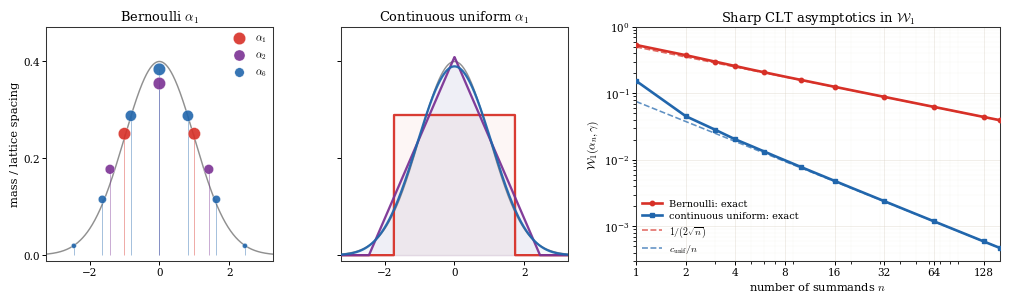

In [5]:
SNAPSHOT_ORDERS = (1, 2, 6)
SNAPSHOT_LABELS = (r"$\alpha_1$", r"$\alpha_2$", r"$\alpha_6$")
SNAPSHOT_COLORS = (RED, VIOLET, BLUE)


def style_snapshot_axis(ax, title):
    """Apply the common compact style to a distribution panel.

    Args:
        ax: Matplotlib axis to style.
        title: Panel title.

    Returns:
        None. The supplied axis is modified in place.
    """
    ax.set_title(title, fontsize=9.4, pad=4)
    ax.set_xlim(-3.25, 3.25)
    ax.set_ylim(-0.012, 0.47)
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([0.0, 0.2, 0.4])
    ax.tick_params(labelsize=7.5, pad=1.5)
    box_axes(ax)


def draw_bernoulli_snapshots(ax):
    """Draw selected normalized Bernoulli convolution laws.

    Args:
        ax: Matplotlib axis receiving the atom displays.

    Returns:
        None. The supplied axis is modified in place.
    """
    grid = np.linspace(-3.35, 3.35, 900)
    ax.plot(grid, gaussian_pdf(grid), color=GRAY, lw=1.05, alpha=0.62, zorder=1)

    for order, label, color in zip(
        SNAPSHOT_ORDERS, SNAPSHOT_LABELS, SNAPSHOT_COLORS
    ):
        support, weights = bernoulli_laws[order]
        spacing = float(np.median(np.diff(support)))
        heights = weights / spacing
        ax.vlines(
            support, 0.0, heights, color=color, lw=0.68, alpha=0.42, zorder=2
        )
        sizes = 7.0 + 72.0 * (heights / heights.max()) ** 0.8
        ax.scatter(
            support,
            heights,
            s=sizes,
            color=color,
            edgecolor="white",
            linewidth=0.25,
            alpha=0.90,
            label=label,
            zorder=3,
        )

    style_snapshot_axis(ax, r"Bernoulli $\alpha_1$")
    ax.set_ylabel("mass / lattice spacing", fontsize=8.2, labelpad=2)


def draw_uniform_snapshots(ax):
    """Draw exact densities of selected continuous-uniform sums.

    Args:
        ax: Matplotlib axis receiving the density curves.

    Returns:
        None. The supplied axis is modified in place.
    """
    grid = np.linspace(-3.35, 3.35, 1400)
    ax.plot(grid, gaussian_pdf(grid), color=GRAY, lw=1.05, alpha=0.62, zorder=1)

    for order, label, color in zip(
        SNAPSHOT_ORDERS, SNAPSHOT_LABELS, SNAPSHOT_COLORS
    ):
        density = standardized_uniform_sum_pdf(grid, order)
        ax.plot(
            grid,
            density,
            color=color,
            lw=1.65,
            alpha=0.94,
            label=label,
            zorder=3,
        )
        ax.fill_between(grid, 0.0, density, color=color, alpha=0.045, zorder=2)

    style_snapshot_axis(ax, r"Continuous uniform $\alpha_1$")
    ax.set_yticklabels([])


fig = plt.figure(figsize=(10.2, 3.25))
grid_spec = fig.add_gridspec(
    1, 3, width_ratios=(1.28, 1.28, 2.05), wspace=0.25
)
axes = [fig.add_subplot(grid_spec[0, index]) for index in range(3)]

draw_bernoulli_snapshots(axes[0])
draw_uniform_snapshots(axes[1])
axes[0].legend(
    loc="upper right",
    frameon=False,
    fontsize=7.4,
    handlelength=1.4,
    borderpad=0.1,
)

rate_ax = axes[2]
marker_indices = np.array([0, 1, 2, 3, 5, 9, 15, 31, 63, 127, 159])
rate_ax.loglog(
    n_values,
    bernoulli_errors,
    color=RED,
    lw=1.9,
    marker="o",
    markevery=marker_indices,
    ms=3.2,
    label="Bernoulli: exact",
    zorder=4,
)
rate_ax.loglog(
    n_values,
    uniform_errors,
    color=BLUE,
    lw=1.9,
    marker="s",
    markevery=marker_indices,
    ms=3.0,
    label="continuous uniform: exact",
    zorder=4,
)
rate_ax.loglog(
    n_values,
    bernoulli_asymptotic,
    color=RED,
    lw=1.15,
    ls="--",
    alpha=0.72,
    label=r"$1/(2\sqrt{n})$",
    zorder=2,
)
rate_ax.loglog(
    n_values,
    uniform_asymptotic,
    color=BLUE,
    lw=1.15,
    ls="--",
    alpha=0.72,
    label=r"$c_{\rm unif}/n$",
    zorder=2,
)
rate_ax.set_title(r"Sharp CLT asymptotics in $\mathcal{W}_1$", fontsize=9.4, pad=4)
rate_ax.set_xlabel(r"number of summands $n$", fontsize=8.2, labelpad=2)
rate_ax.set_ylabel(r"$\mathcal{W}_1(\alpha_n,\gamma)$", fontsize=8.2, labelpad=2)
rate_ax.set_xlim(1.0, N_MAX)
rate_ax.set_ylim(3e-4, 1.0)
rate_ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128])
rate_ax.set_xticklabels(["1", "2", "4", "8", "16", "32", "64", "128"])
rate_ax.grid(True, which="major", color=LIGHT_GRAY, lw=0.45, alpha=0.58)
rate_ax.grid(True, which="minor", color=LIGHT_GRAY, lw=0.25, alpha=0.24)
rate_ax.tick_params(labelsize=7.5, pad=1.5)
box_axes(rate_ax)
rate_ax.legend(
    loc="lower left",
    frameon=False,
    fontsize=7.05,
    handlelength=2.0,
    borderpad=0.1,
    labelspacing=0.32,
)

fig.subplots_adjust(left=0.06, right=0.995, bottom=0.18, top=0.90)
save_pdf(fig, OUT / "comparison.pdf", pad_inches=0.025)
fig.savefig(THUMBNAIL, dpi=220, bbox_inches="tight", pad_inches=0.025)
plt.show()
plt.close(fig)
